Data types of columns:
Domain           object
Have_IP           int64
Have_At           int64
URL_Length        int64
URL_Depth         int64
Redirection       int64
https_Domain      int64
TinyURL           int64
Prefix/Suffix     int64
DNS_Record        int64
Web_Traffic       int64
Domain_Age        int64
Domain_End        int64
iFrame            int64
Mouse_Over        int64
Right_Click       int64
Web_Forwards      int64
Label             int64
dtype: object
Before SMOTE: Class distribution in y_train: Label
1    4012
0    3988
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: Label
1    4012
0    4012
Name: count, dtype: int64
Feature Importances:
                     Feature  Importance
3                URL_Length    6.523292
0                    Domain    3.456971
8             Prefix/Suffix    0.945086
4                 URL_Depth    0.650466
11               Domain_Age    0.396333
16             Web_Forwards    0.393548
17       Domain & URL_Dept

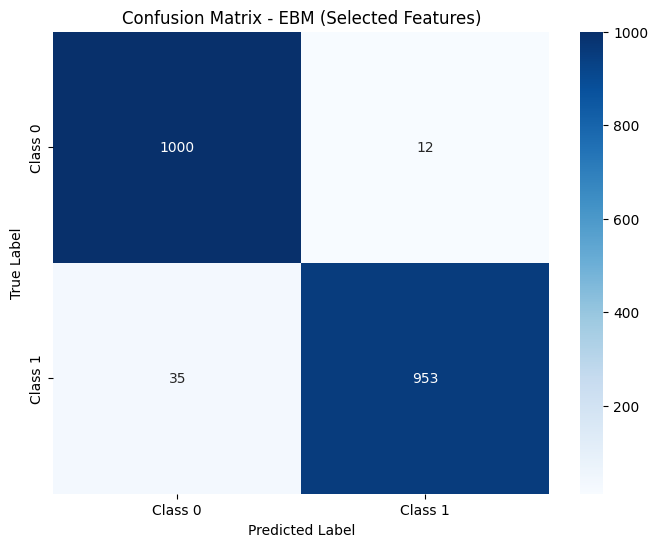

<!-- http://127.0.0.1:7001/1703405938992/ -->

<!-- http://127.0.0.1:7001/1703428471360/ -->

In [11]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()

# Step 1: Load dataset
df = pd.read_csv('ds_10K18.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select top n features (let's select top 10 features for this example)
top_n = 10
top_features = feature_importances['Feature'].head(top_n).values

# Align the feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in top_features]]

print(f"Aligned Top {top_n} selected features: {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")
print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
id                                      int64
NumDots                                 int64
SubdomainLevel                          int64
PathLevel                               int64
UrlLength                               int64
NumDash                                 int64
NumDashInHostname                       int64
AtSymbol                                int64
TildeSymbol                             int64
NumUnderscore                           int64
NumPercent                              int64
NumQueryComponents                      int64
NumAmpersand                            int64
NumHash                                 int64
NumNumericChars                         int64
NoHttps                                 int64
RandomString                            int64
IpAddress                               int64
DomainInSubdomains                      int64
DomainInPaths                           int64
HttpsInHostname                         int64
HostnameLen

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


After SMOTE: Class distribution in y_train_resampled: CLASS_LABEL
0    4012
1    4012
Name: count, dtype: int64
Feature Importances:
                                Feature  Importance
26                    PctExtHyperlinks    1.673679
33       PctNullSelfRedirectHyperlinks    1.265779
4                              NumDash    1.104497
29                       InsecureForms    0.953620
47  PctExtNullSelfRedirectHyperlinksRT    0.915931
..                                 ...         ...
23                   DoubleSlashInPath    0.004966
6                             AtSymbol    0.002976
25                   EmbeddedBrandName    0.002782
35                 FakeLinkInStatusBar    0.001885
19                     HttpsInHostname    0.000000

[92 rows x 2 columns]
Aligned Top 5 selected features: ['NumDash', 'PctExtHyperlinks', 'InsecureForms', 'PctNullSelfRedirectHyperlinks', 'PctExtNullSelfRedirectHyperlinksRT']
Running time: 13.03565 seconds
EBM Accuracy (Selected Features): 0.953
EBM ROC

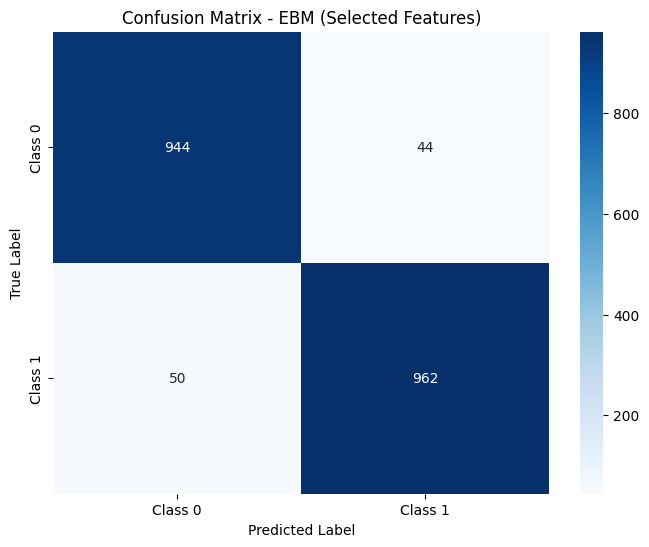

<!-- http://127.0.0.1:7001/1703428332992/ -->

<!-- http://127.0.0.1:7001/1703428327376/ -->

In [13]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_10K50.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,1:]
X=X1.iloc[:,:-1]
#X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select top n features (let's select top 10 features for this example)
top_n = 5
top_features = feature_importances['Feature'].head(top_n).values

# Align the feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in top_features]]

print(f"Aligned Top {top_n} selected features: {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")
print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
num_dots_url            int64
num_hyph_url            int64
num_underline_url       int64
num_slash_url           int64
num_questionmark_url    int64
                        ...  
num_percent_param       int64
length_param            int64
tld_in_param            int64
num_param               int64
phishing                int64
Length: 75, dtype: object
Before SMOTE: Class distribution in y_train: phishing
0    4004
1    3996
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: phishing
1    4004
0    4004
Name: count, dtype: int64
Feature Importances:
            Feature  Importance
40     length_path    0.997647
23      length_dom    0.902982
17      length_url    0.684944
53     length_file    0.409731
22  num_vowels_dom    0.296547
..             ...         ...
45    at_sign_file    0.000448
37   num_plus_path    0.000443
51   num_plus_file    0.000443
64     tilde_param    0.000404
49      tilde_file    0.000000

[139 rows x 2 col

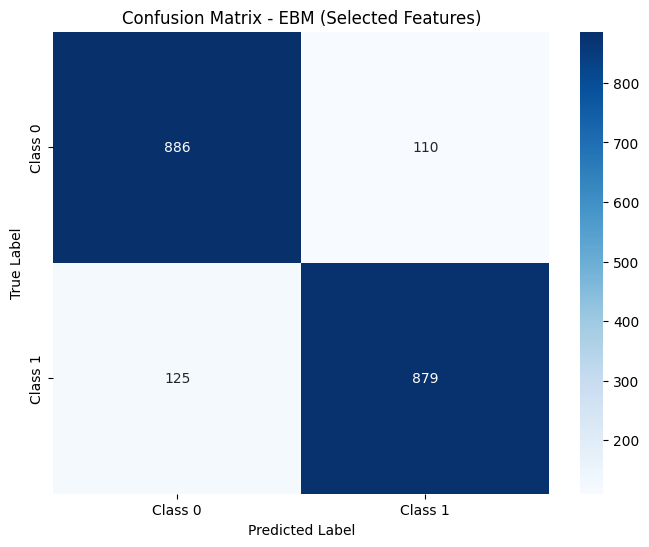

<!-- http://127.0.0.1:7001/2766240825856/ -->

<!-- http://127.0.0.1:7001/2766086091600/ -->

In [50]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('ds_10K75.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,1:]
X=X1.iloc[:,:-1]
#X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select top n features (let's select top 10 features for this example)
top_n = 5
top_features = feature_importances['Feature'].head(top_n).values

# Align the feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in top_features]]

print(f"Aligned Top {top_n} selected features: {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
index                          int64
having_IPhaving_IP_Address     int64
URLURL_Length                  int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic    

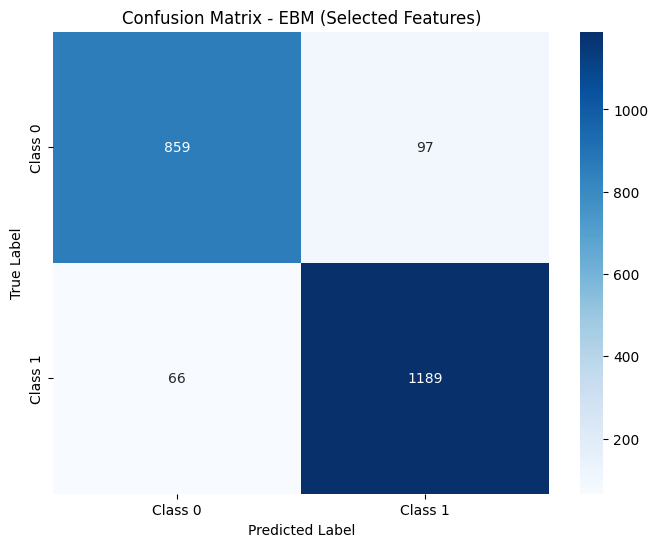

<!-- http://127.0.0.1:7001/2766937908256/ -->

<!-- http://127.0.0.1:7001/2766789376672/ -->

In [52]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('ds_11055.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,1:]
X=X1.iloc[:,:-1]
#X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select top n features (let's select top 10 features for this example)
top_n = 5
top_features = feature_importances['Feature'].head(top_n).values

# Align the feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in top_features]]

print(f"Aligned Top {top_n} selected features: {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
url                object
length_url          int64
length_hostname     int64
ip                 object
nb_dots             int64
                    ...  
web_traffic         int64
dns_record          int64
google_index        int64
page_rank           int64
status             object
Length: 89, dtype: object
Before SMOTE: Class distribution in y_train: 0    4604
1    4580
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: 0    4604
1    4604
Name: count, dtype: int64
Feature Importances:
                  Feature    Importance
86             page_rank  1.635158e+00
85          google_index  1.453383e+00
50           phish_hints  8.779861e-01
20                nb_www  8.218802e-01
56         nb_hyperlinks  6.884825e-01
..                   ...           ...
71                   sfh  3.025118e-23
59  ratio_nullHyperlinks  3.025118e-23
61  ratio_intRedirection  3.781397e-24
63       ratio_intErrors  0.000000e+00
8                  nb_o

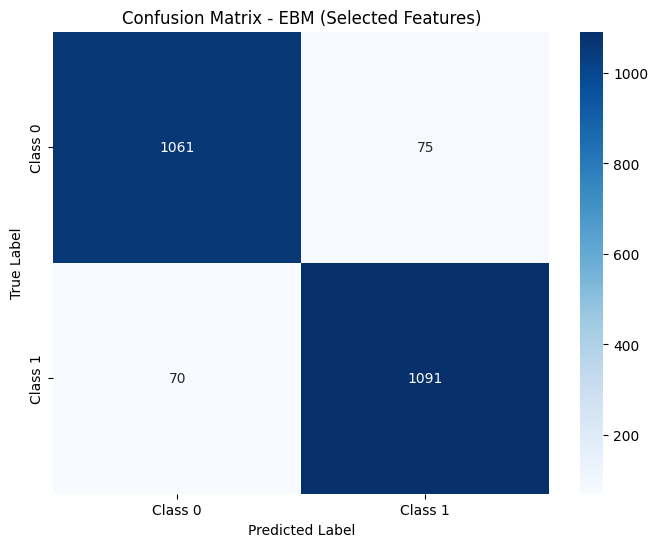

<!-- http://127.0.0.1:7001/2766947033520/ -->

<!-- http://127.0.0.1:7001/2766946940640/ -->

In [54]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('ds_11K89.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,1:]
X=X1.iloc[:,:-1]
#X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select top n features (let's select top 10 features for this example)
top_n = 5
top_features = feature_importances['Feature'].head(top_n).values

# Align the feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in top_features]]

print(f"Aligned Top {top_n} selected features: {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
qty_dot_url             int64
qty_hyphen_url          int64
qty_underline_url       int64
qty_slash_url           int64
qty_questionmark_url    int64
                        ...  
qty_redirects           int64
url_google_index        int64
domain_google_index     int64
url_shortened           int64
phishing                int64
Length: 112, dtype: object
Before SMOTE: Class distribution in y_train: phishing
0    46388
1    24529
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: phishing
0    46388
1    46388
Name: count, dtype: int64
Feature Importances:
                    Feature    Importance
99  time_domain_activation  1.619355e+00
17              length_url  1.220401e+00
18          qty_dot_domain  1.000222e+00
56        directory_length  8.205284e-01
98                  asn_ip  6.668212e-01
..                     ...           ...
27        qty_space_domain  4.840188e-22
28        qty_tilde_domain  1.210047e-22
29        qty_co

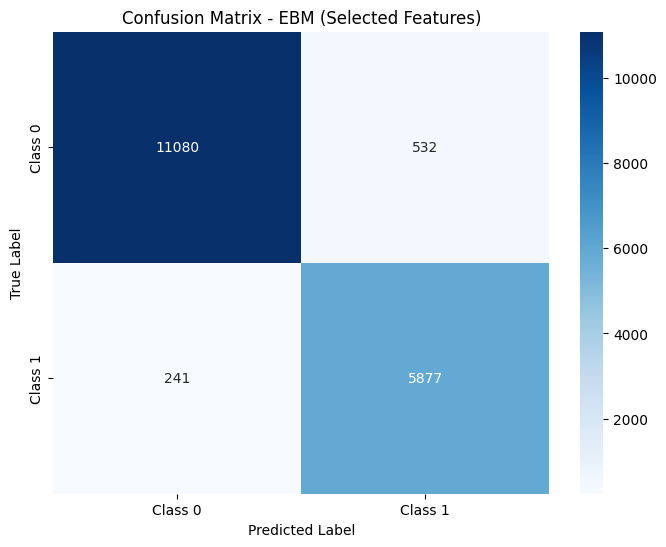

<!-- http://127.0.0.1:7001/2766947028816/ -->

<!-- http://127.0.0.1:7001/2766088618928/ -->

In [42]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('ds_88K112.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,1:]
X=X1.iloc[:,:-1]
#X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select top n features (let's select top 10 features for this example)
top_n = 5
top_features = feature_importances['Feature'].head(top_n).values

# Align the feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in top_features]]

print(f"Aligned Top {top_n} selected features: {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
url_length        int64
n_dots            int64
n_hypens          int64
n_underline       int64
n_slash           int64
n_questionmark    int64
n_equal           int64
n_at              int64
n_and             int64
n_exclamation     int64
n_space           int64
n_tilde           int64
n_comma           int64
n_plus            int64
n_asterisk        int64
n_hastag          int64
n_dollar          int64
n_percent         int64
n_redirection     int64
phishing          int64
dtype: object
Before SMOTE: Class distribution in y_train: phishing
0    51017
1    29044
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: phishing
0    51017
1    51017
Name: count, dtype: int64
Feature Importances:
                            Feature  Importance
3                          n_slash    1.704064
0                           n_dots    0.438304
1                         n_hypens    0.416889
25              n_hypens & n_slash    0.219898
19           

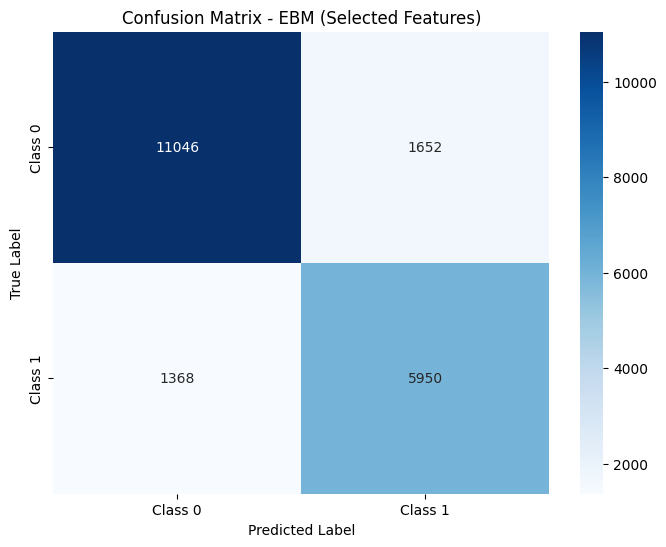

<!-- http://127.0.0.1:7001/2766938456032/ -->

<!-- http://127.0.0.1:7001/2766929146224/ -->

In [43]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('ds_100K20.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,1:]
X=X1.iloc[:,:-1]
#X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select top n features (let's select top 10 features for this example)
top_n = 5
top_features = feature_importances['Feature'].head(top_n).values

# Align the feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in top_features]]

print(f"Aligned Top {top_n} selected features: {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
qty_dot_url             int64
qty_hyphen_url          int64
qty_underline_url       int64
qty_slash_url           int64
qty_questionmark_url    int64
                        ...  
qty_redirects           int64
url_google_index        int64
domain_google_index     int64
url_shortened           int64
phishing                int64
Length: 112, dtype: object
Before SMOTE: Class distribution in y_train: phishing
0    62155
1    41603
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: phishing
1    62155
0    62155
Name: count, dtype: int64
Feature Importances:
                    Feature  Importance
17              length_url    1.823111
99  time_domain_activation    1.693270
18          qty_dot_domain    1.019957
56        directory_length    0.947978
98                  asn_ip    0.928585
..                     ...         ...
29        qty_comma_domain    0.000000
34      qty_percent_domain    0.000000
27        qty_space_domain    0.00

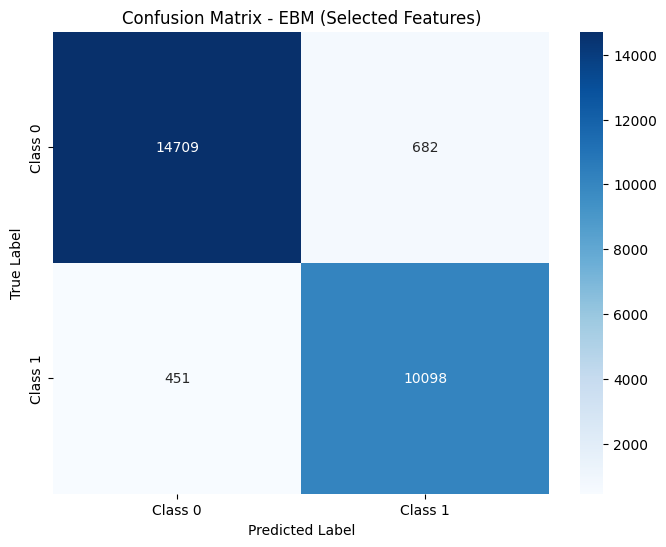

<!-- http://127.0.0.1:7001/2766952337616/ -->

<!-- http://127.0.0.1:7001/2766899215056/ -->

In [56]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('ds_129K112.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,1:]
X=X1.iloc[:,:-1]
#X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select top n features (let's select top 10 features for this example)
top_n = 5
top_features = feature_importances['Feature'].head(top_n).values

# Align the feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in top_features]]

print(f"Aligned Top {top_n} selected features: {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                    

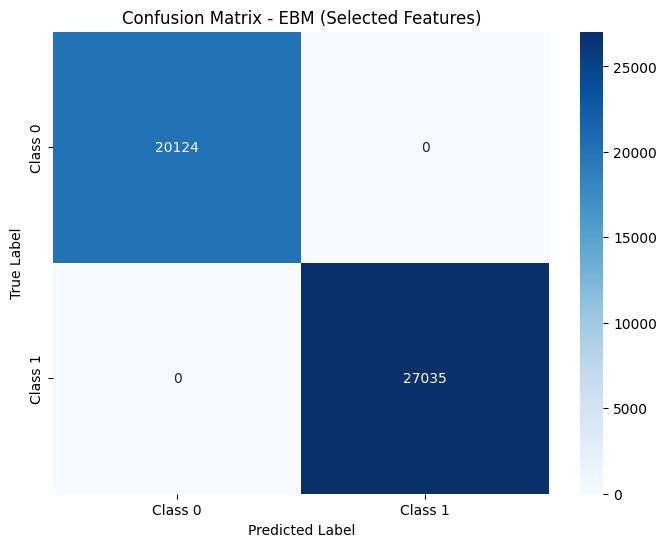

<!-- http://127.0.0.1:7001/2766240833056/ -->

<!-- http://127.0.0.1:7001/2766946929504/ -->

In [38]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('ds_235795_54.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,1:]
X=X1.iloc[:,:-1]
#X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select top n features (let's select top 10 features for this example)
top_n = 5
top_features = feature_importances['Feature'].head(top_n).values

# Align the feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in top_features]]

print(f"Aligned Top {top_n} selected features: {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
Domain           object
Have_IP           int64
Have_At           int64
URL_Length        int64
URL_Depth         int64
Redirection       int64
https_Domain      int64
TinyURL           int64
Prefix/Suffix     int64
DNS_Record        int64
Web_Traffic       int64
Domain_Age        int64
Domain_End        int64
iFrame            int64
Mouse_Over        int64
Right_Click       int64
Web_Forwards      int64
Label             int64
dtype: object
Before SMOTE: Class distribution in y_train: Label
1    4012
0    3988
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: Label
1    4012
0    4012
Name: count, dtype: int64
Feature Importances:
                     Feature  Importance
3                URL_Length    6.523292
0                    Domain    3.456971
8             Prefix/Suffix    0.945086
4                 URL_Depth    0.650466
11               Domain_Age    0.396333
16             Web_Forwards    0.393548
17       Domain & URL_Dept

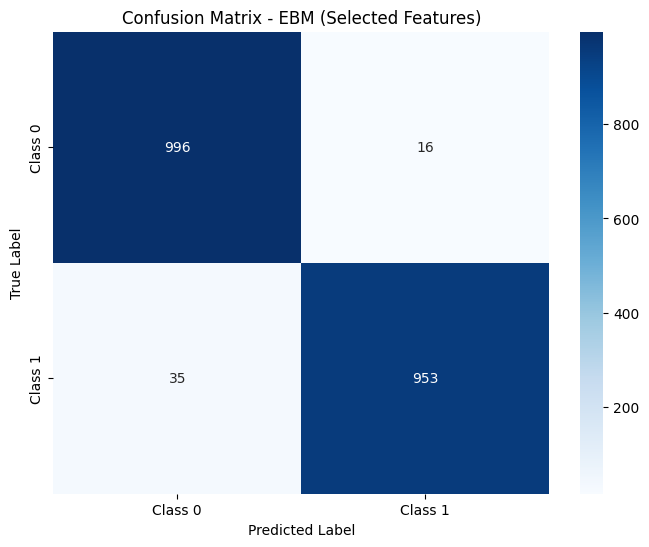

<!-- http://127.0.0.1:7001/2766271206736/ -->

<!-- http://127.0.0.1:7001/2766270951792/ -->

In [36]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('ds_10K18.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select top n features based on EBM feature importance (let's select top 10 features for this example)
top_n = 5
top_features = feature_importances['Feature'].head(top_n).values

# Align the feature names with the DataFrame columns
# Convert feature names to lowercase for comparison and remove leading/trailing spaces to handle mismatches
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in top_features]]

print(f"Aligned Top {top_n} selected features: {aligned_features}")

# Reduce training and testing data to include only selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
index                          int64
having_IPhaving_IP_Address     int64
URLURL_Length                  int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic    

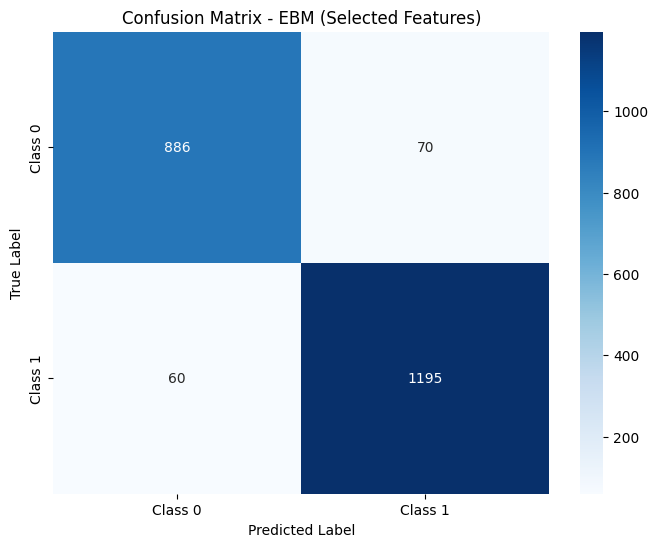

<!-- http://127.0.0.1:7001/1703428425968/ -->

<!-- http://127.0.0.1:7001/1703428329392/ -->

In [15]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('ds_11055.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1 = df.iloc[:, 2:]
X=X1.iloc[:,:-1]
#X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select features based on the first quartile (Q1) of importance scores
# Calculate the first quartile (Q1) value
Q1_importance = feature_importances['Importance'].quantile(0.25)

# Select features with importance greater than or equal to Q1
selected_features = feature_importances[feature_importances['Importance'] >= Q1_importance]['Feature'].values

# Align the selected feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in selected_features]]

print(f"Aligned Selected Features (Based on Q1): {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)


Data types of columns:
index                          int64
having_IPhaving_IP_Address     int64
URLURL_Length                  int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic    

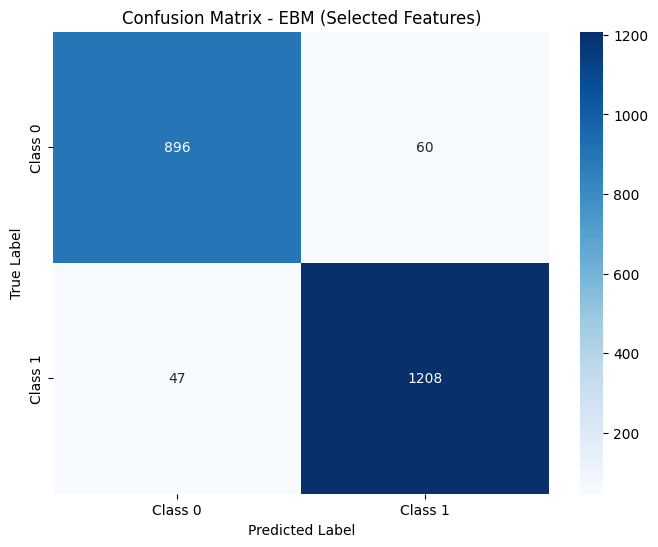

<!-- http://127.0.0.1:7001/1703440236960/ -->

<!-- http://127.0.0.1:7001/1703428879904/ -->

In [17]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('ds_11055.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
#X1 = df.iloc[:, 2:]
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Train EBM model to get feature importances
prelim_ebm_model = ExplainableBoostingClassifier(random_state=42)
prelim_ebm_model.fit(X_train_resampled, y_train_resampled)

# Extract feature importances from the EBM model
global_explanation = prelim_ebm_model.explain_global(name='EBM Feature Importance')
feature_importances = pd.DataFrame({
    'Feature': global_explanation.data()['names'],
    'Importance': global_explanation.data()['scores']
})

# Sort the features by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Step 6: Select features based on the first quartile (Q1) of importance scores
# Calculate the first quartile (Q1) value
Q1_importance = feature_importances['Importance'].quantile(0.01)

# Select features with importance greater than or equal to Q1
selected_features = feature_importances[feature_importances['Importance'] >= Q1_importance]['Feature'].values

# Align the selected feature names with the DataFrame columns
# Strip spaces and lower case to handle any mismatches in column names
aligned_features = [col for col in X_train_resampled.columns if col.strip().lower() in [f.strip().lower() for f in selected_features]]

print(f"Aligned Selected Features (Based on Q1): {aligned_features}")

# Reduce training and testing data to include only aligned selected top features
X_train_selected = X_train_resampled[aligned_features]
X_test_selected = X_test[aligned_features]

# Step 7: Train final EBM model with selected features
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_selected, y_train_resampled)

# Step 8: Predict and evaluate model
y_pred = ebm_model.predict(X_test_selected)
y_proba = ebm_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
ebm_accuracy = accuracy_score(y_test, y_pred)
ebm_roc_auc = roc_auc_score(y_test, y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 9: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - EBM (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 10: Visualize global explanations using EBM
ebm_global = ebm_model.explain_global()
show(ebm_global)

# Step 11: Visualize local explanations using EBM for a single instance
# Show local explanation for the first instance in the test set
ebm_local = ebm_model.explain_local(X_test_selected[:1], y_test[:1])
show(ebm_local)
